# Final Project Notebook

> Last Day to submit dataset selection is October 7th

## Useful Links
* [Linear Models](https://scikit-learn.org/stable/modules/linear_model.html)
* [Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html)

The idea is to evaluate classifiers 

### Getting Started 

* Simple SVM file, modify to do Linear Regression
* Compare Linear Models or Neutral Network vs Linear Models
* Work on the one pager

### Project Work
Comparison of two models in test accuracy and training runtime

* Pick two models
* Pick two medium to large datasets
* Perform cross validation

**Linear models**: Linear Regression and Support Vector Machine
**Non-linear models**: Neural Networks

#### Data Sources

* [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/) - https://archive.ics.uci.edu/
* [Kaggle](https://www.kaggle.com/) - https://www.kaggle.com/
* [Google Datasets](https://datasetsearch.research.google.com/) - https://datasetsearch.research.google.com/
* [Papers with code](https://paperswithcode.com/) - https://paperswithcode.com/

####  Problem domains
* Image Classification - popular benchmarks are CIFAR10, CIFAR100, IMAGENET, STL10, MNIST
* Video Classification
* Image Segmentation
* Image Localization
* Tabular Data - business data such as insurance, time series data

Email the one pager,
Request a meeting to discuss meeting

#### Presentation 
Final Presentation is a Powerpoint Slide with results and code

#### Cross Validation 

```mermaid
flowchart LR
    Data_with_Labels[Data With Labels] --> Train
    Data_with_Labels --> Validation
    Train --> Learn[Learn a model on the training dataset only. In this step it’s extremely important that we don’t look at the validation labels. This means even for feature selection we don’t look at the validation labels.]
    Learn --> Predict[Predict on Validation Dataset]
    Predict --> Report[Report the accuracy on validation because we do have the validation labels]
```

### Five-Fold Cross Validation
`cross_val_score` - Does 5 fold cross validation

Divide data to 5 parts, 

```mermaid
flowchart TD 
    Part_0[Part 0]
    Part_1[Part 1]
    Part_2[Part 2]
    Part_3[Part 3]
    Part_4[Part 4]    
```
####  Balanced Error 

| True | Pred |
|---|---|
| 0 | 0 | 
| 0 | 0 | 
| 0 | 0 | 
| 0 | 0 | 
| 0 | 0 | 
| 0 | 0 | 
| 0 | 0 | 
| 0 | 0 | 
| 0 | 0 | 
| 1 | 0 | 

The error that we typically measure is the `01` loss risk. This can be misleading for imbalanced datasets. Consider the above example. By simply outputting all predictions as the majority class we get a low error of `0.1`. But this is misleading because we have a simple trivial classifier.

```
Imbalanced Error = 1/10 = 0.1
```

We can correct for this by measuring the balanced error. This is simply the average 01 loss (error) across each class. In the above example the error in predicting class `0` is `0%`. But the error in predicting class `1` is `100%`. Thus the balanced error is

```
Balanced error = (100+0)/2 = 50% (or 0.5).
```

#### Using SciKit
To get the true error you need to do class wise. Check for error in each class. This can be validated using `cross_val_score`.

The more off data is, you need to use balanced error

### One Hot Encoding 
More accurate than label encoding, it converts categories to vector encoding. The dataset is ready for cross validation. One dataset, give details ~ Do Neutral Networks

Linear Regression vs CNN for Images


--- 


# CV Project Dataset Ideas

* [STL-10](https://cs.stanford.edu/~acoates/stl10/) ~ 2.5GB of data
* [LeRobot push_image](https://huggingface.co/datasets/lerobot/pusht_image) ~ What do I classify on here ?
* [BridgeData](https://rail-berkeley.github.io/bridgedata/)
* [RobotNet](https://www.robonet.wiki/) 

## Idea So Far

### Models compared

Linear Support Vector Machine vs. Neural Network (CNN)

Before committing, review how to build a CNN using TensorFlow or Keras, also check notes from website, if there is directions there.

In [ ]:
# ~ uncomment to use
#%pip install scipy imageio

### Code to view images in the binary
Contains all the necessary code for reading binary image data along with a function for displaying an image.

Thanks to Martin Tutek for the python code to load/view STL-10! [Python code](https://github.com/mttk/STL10)

sys.version_info(major=3, minor=13, micro=15, releaselevel='final', serial=0)


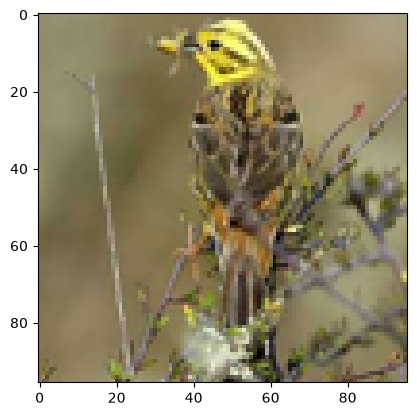

(5000, 96, 96, 3)
(5000,)


In [ ]:
import sys
import os, sys, errno
import numpy as np
import matplotlib.pyplot as plt
    
from imageio import imsave

print(sys.version_info) 

# image shape
HEIGHT = 96
WIDTH = 96
DEPTH = 3

# size of a single image in bytes
SIZE = HEIGHT * WIDTH * DEPTH

# path to the directory with the data
DATA_DIR = './data'

# path to the binary train file with image data
DATA_PATH = './stl-10/train_X.bin'

# path to the binary train file with labels
LABEL_PATH = './stl-10/train_y.bin'

def read_labels(path_to_labels):
    """
    :param path_to_labels: path to the binary file containing labels from the STL-10 dataset
    :return: an array containing the labels
    """
    with open(path_to_labels, 'rb') as f:
        labels = np.fromfile(f, dtype=np.uint8)
        return labels


def read_all_images(path_to_data):
    """
    :param path_to_data: the file containing the binary images from the STL-10 dataset
    :return: an array containing all the images
    """

    with open(path_to_data, 'rb') as f:
        # read whole file in uint8 chunks
        everything = np.fromfile(f, dtype=np.uint8)

        # We force the data into 3x96x96 chunks, since the
        # images are stored in "column-major order", meaning
        # that "the first 96*96 values are the red channel,
        # the next 96*96 are green, and the last are blue."
        # The -1 is since the size of the pictures depends
        # on the input file, and this way numpy determines
        # the size on its own.

        images = np.reshape(everything, (-1, 3, 96, 96))

        # Now transpose the images into a standard image format
        # readable by, for example, matplotlib.imshow
        # You might want to comment this line or reverse the shuffle
        # if you will use a learning algorithm like CNN, since they like
        # their channels separated.
        images = np.transpose(images, (0, 3, 2, 1))
        return images


def read_single_image(image_file):
    """
    CAREFUL! - this method uses a file as input instead of the path - so the
    position of the reader will be remembered outside of context of this method.
    :param image_file: the open file containing the images
    :return: a single image
    """
    # read a single image, count determines the number of uint8's to read
    image = np.fromfile(image_file, dtype=np.uint8, count=SIZE)
    # force into image matrix
    image = np.reshape(image, (3, 96, 96))
    # transpose to standard format
    # You might want to comment this line or reverse the shuffle
    # if you will use a learning algorithm like CNN, since they like
    # their channels separated.
    image = np.transpose(image, (2, 1, 0))
    return image


def plot_image(image):
    """
    :param image: the image to be plotted in a 3-D matrix format
    :return: None
    """
    plt.imshow(image)
    plt.show()

def save_image(image, name):
    imsave(uri="%s.png" % name, im= image)

def save_images(images, labels):
    print("Saving images to disk")
    i = 0
    for image in images:
        label = labels[i]
        directory = './img/' + str(label) + '/'
        try:
            os.makedirs(directory, exist_ok=True)
        except OSError as exc:
            if exc.errno == errno.EEXIST:
                pass
        filename = directory + str(i)
        print(filename)
        save_image(image, filename)
        i = i+1

with open(DATA_PATH) as f:
    image = read_single_image(f)
    plot_image(image)

    # # test to check if the whole dataset is read correctly
    images = read_all_images(DATA_PATH)
    print(images.shape)

    labels = read_labels(LABEL_PATH)
    print(labels.shape)

    # # save images to disk
    # save_images(images, labels)